In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import string

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [2]:
def get_df_from_nc(ds, var):
    ds = ds.sel(location=location,time=slice("2025-08-07", "2025-08-10 12:00"))
    time_dim = ds[var].dims[0]
    z_mc = ds['z_mc'].values
    height_values = z_mc - (z_mc[-1] - 5)
    df = pd.DataFrame(ds[var].values.T, index=height_values, columns=pd.to_datetime(ds[time_dim],utc=True))
    return df

## Script settings

In [3]:
location = 'Q272'

var = 'theta'
offset = 0
skip = 3


## Get data

The data used for this figure is available at Zenodo:

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19596612.svg)](https://doi.org/10.5281/zenodo.19596612)

In [4]:
# load data
ds_icon = xr.open_dataset(data_dir + 'HEFEX3__ICON_v370_2030_uav_locations_50ml__1h_IOP1_20250807-20250811.nc')
ds_uav  = xr.open_dataset(data_dir + 'HEFEX3__Obs_UAV_profiles_L2__1h_20250807-20250811.nc')

df_icon = get_df_from_nc(ds_icon, var)
df_uav  = get_df_from_nc(ds_uav, f'{var}_ml')

In [5]:
ds_icon.sel(location=location).ele_icon.values

array(2798.971191)

## Create plot

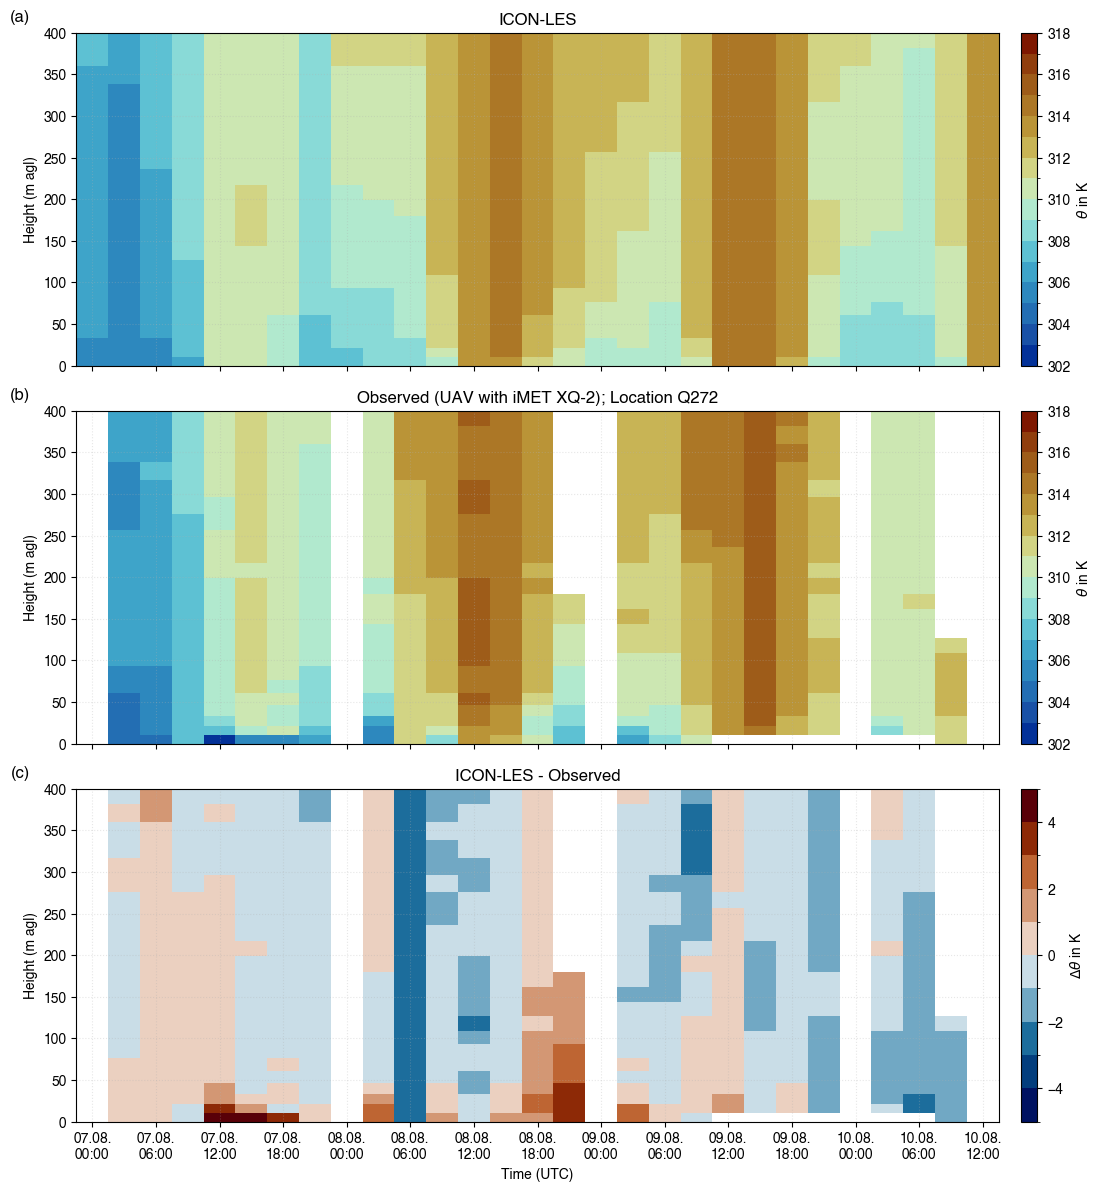

In [6]:
# discrete colors
cmap = cm.roma_r  # Red-Yellow-Blue colormap
norm = mcolors.BoundaryNorm(np.arange(302,319,1), ncolors=cmap.N, clip=True)


fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True, sharey=True)

ax = axs[0]
pm = ax.pcolormesh(df_icon.columns[offset::skip], df_icon.index, df_icon.iloc[::, offset::skip], cmap=cmap, norm=norm)
fig.colorbar(pm, ax=ax, label=r"$\theta$ in K", pad=0.02)
ax.set_title('ICON-LES')

ax = axs[1]
pm = ax.pcolormesh(df_uav.columns[offset::skip], df_uav.index, df_uav.iloc[::, offset::skip], cmap=cmap, norm=norm)
fig.colorbar(pm, ax=ax, label=r"$\theta$ in K", pad=0.02)
ax.set_title(f'Observed (UAV with iMET XQ-2); Location {location}')

ax = axs[2]
cmap = cm.vik  # Red-Yellow-Blue colormap
norm = mcolors.BoundaryNorm(np.arange(-5,6,1), ncolors=cmap.N, clip=True)

df_delta = df_icon-df_uav
pm = ax.pcolormesh(df_delta.columns[offset::skip], df_delta.index, df_delta.iloc[::, offset::skip], cmap=cmap, norm=norm)
fig.colorbar(pm, ax=ax, label=r"$\Delta\theta$ in K", pad=0.02)
ax.set_title('ICON-LES - Observed')
ax.set_xlabel('Time (UTC)')

for ax in axs:
    ax.set_ylim(0,400)
    ax.set_ylabel('Height (m agl)')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.\n%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

    ax.grid(True, alpha=.3, ls=':')

# panel letters
for ax, letter in zip(axs.flat, string.ascii_lowercase):
    ax.text(
        -0.05, 1.025, f'({letter})',
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        va='bottom', ha='right'
    )

plt.tight_layout()
plt.savefig(fig_png_dir + f'HEF_UAV_ICON_profile_{location}_{var}.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_UAV_ICON_profile_{location}_{var}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()